<a href="https://www.kaggle.com/code/swaggpale/creditcard-fraud-analysis?scriptVersionId=337720967" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

# Set visualization style for professional reporting
plt.style.use('ggplot')
sns.set_palette("muted")

# 1. Load the dataset
print("Loading data...")
df = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')

# 2. Initial Data Profiling
print("\n--- Basic Dataset Info ---")
print(f"Total Transactions: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
print(f"Missing Values: {df.isnull().sum().max()}") # Should be 0

# Check the exact class imbalance
fraud_percent = round(df['Class'].value_counts()[1] / len(df) * 100, 3)
print(f"\n--- Class Distribution ---")
print(df['Class'].value_counts())
print(f"Fraudulent Transactions represent {fraud_percent}% of the dataset.")

# 3. Handling the Skew: Robust Scaling
# We scale Time and Amount to match the PCA-transformed V1-V28 features.
print("\nScaling Time and Amount using RobustScaler...")
rob_scaler = RobustScaler()

# Create new scaled columns and drop the old ones
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1, 1))

df.drop(['Time', 'Amount'], axis=1, inplace=True)

# Reorder columns to put scaled features at the beginning
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']
df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

print("Scaling complete. Data is ready for EDA.")

Loading data...

--- Basic Dataset Info ---
Total Transactions: 284807
Total Features: 31
Missing Values: 0

--- Class Distribution ---
Class
0    284315
1       492
Name: count, dtype: int64
Fraudulent Transactions represent 0.173% of the dataset.

Scaling Time and Amount using RobustScaler...
Scaling complete. Data is ready for EDA.


/tmp/ipykernel_16/2641343460.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, ax=ax[0], palette=['#3498db', '#e74c3c'])
/tmp/ipykernel_16/2641343460.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Class", y="scaled_amount", data=df, ax=ax[1], palette=['#3498db', '#e74c3c'])


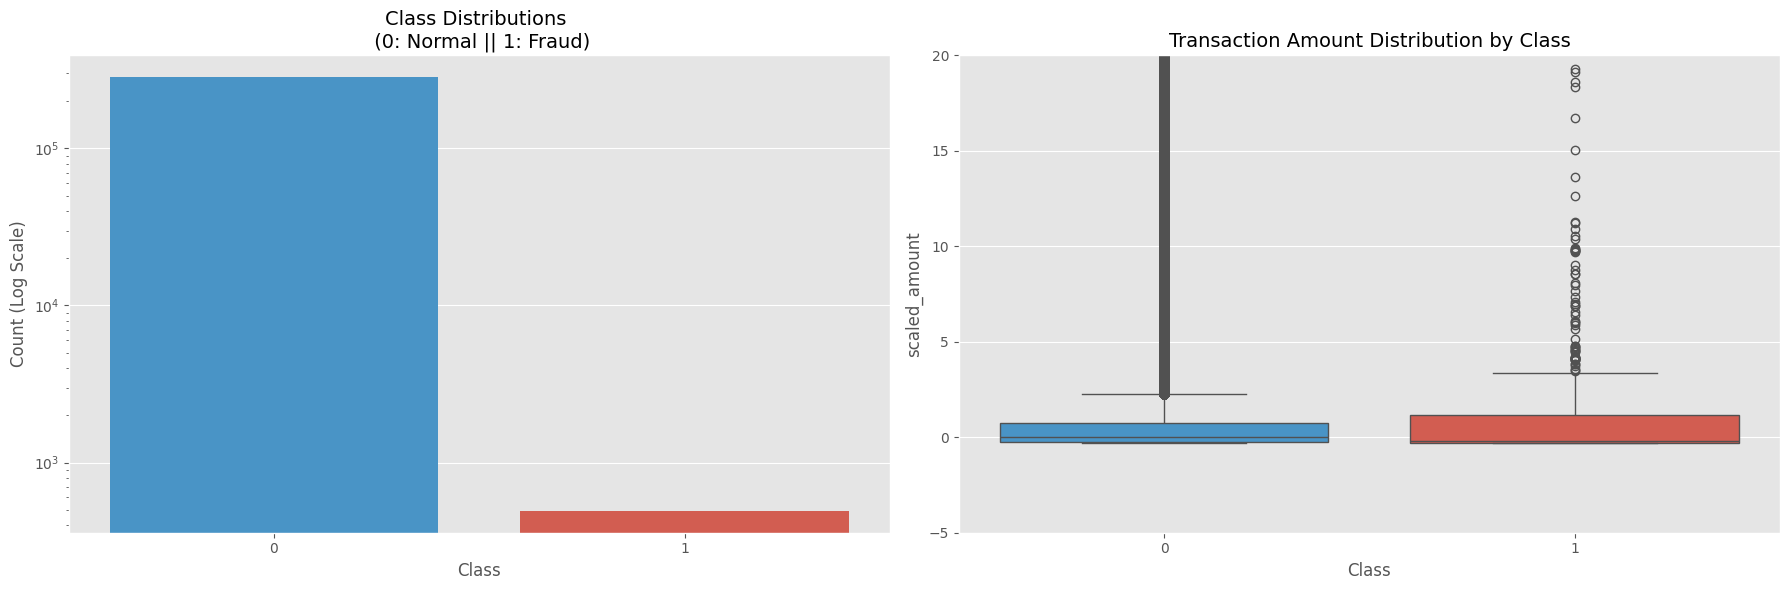

In [3]:
# 4. Visualizing the Data Setup

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: The Class Imbalance
sns.countplot(x='Class', data=df, ax=ax[0], palette=['#3498db', '#e74c3c'])
ax[0].set_title('Class Distributions \n (0: Normal || 1: Fraud)', fontsize=14)
ax[0].set_yscale('log') # Log scale helps visualize the tiny fraud bar
ax[0].set_ylabel('Count (Log Scale)')

# Plot 2: Distribution of Scaled Transaction Amounts by Class
sns.boxplot(x="Class", y="scaled_amount", data=df, ax=ax[1], palette=['#3498db', '#e74c3c'])
ax[1].set_title('Transaction Amount Distribution by Class', fontsize=14)
ax[1].set_ylim(-5, 20) # Zooming in to bypass massive extreme outliers

plt.tight_layout()
plt.show()

In [4]:
# Phase 3: Train/Test Split and SMOTE

from sklearn.model_selection import StratifiedShuffleSplit
from imblearn.over_sampling import SMOTE
import pandas as pd # Assuming pandas is imported, added for self-containment

# 1. Define Features (X) and Target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# 2. Stratified Train/Test Split
# This ensures the 0.17% fraud ratio is preserved in both train and test sets
print("Splitting data (Stratified)...")
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in sss.split(X, y):
    # Use .iloc to slice the dataframe safely
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

# Verify the split worked correctly
print("\n--- Split Verification ---")
print(f"Original Fraud Ratio: {round(y.value_counts()[1]/len(y) * 100, 3)}%")
print(f"Training Fraud Ratio: {round(y_train.value_counts()[1]/len(y_train) * 100, 3)}%")
print(f"Testing Fraud Ratio:  {round(y_test.value_counts()[1]/len(y_test) * 100, 3)}%")

# 3. Apply SMOTE to the TRAINING DATA ONLY
print("\nApplying SMOTE to training data (This might take a moment)...")
smote = SMOTE(sampling_strategy='minority', random_state=42)

# X_sm and y_sm are our new, balanced training datasets
X_sm, y_sm = smote.fit_resample(X_train, y_train)

print("\n--- SMOTE Verification ---")
print(f"Before SMOTE, Normal (0): {y_train.value_counts()[0]}, Fraud (1): {y_train.value_counts()[1]}")
print(f"After SMOTE, Normal (0): {y_sm.value_counts()[0]}, Fraud (1): {y_sm.value_counts()[1]}")

Splitting data (Stratified)...

--- Split Verification ---
Original Fraud Ratio: 0.173%
Training Fraud Ratio: 0.173%
Testing Fraud Ratio:  0.172%

Applying SMOTE to training data (This might take a moment)...

--- SMOTE Verification ---
Before SMOTE, Normal (0): 227451, Fraud (1): 394
After SMOTE, Normal (0): 227451, Fraud (1): 227451


Training Logistic Regression (Baseline)...
Training XGBoost Classifier (This may take a moment)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:15:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.72      0.86      0.78        98

    accuracy                           1.00     56962
   macro avg       0.86      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962



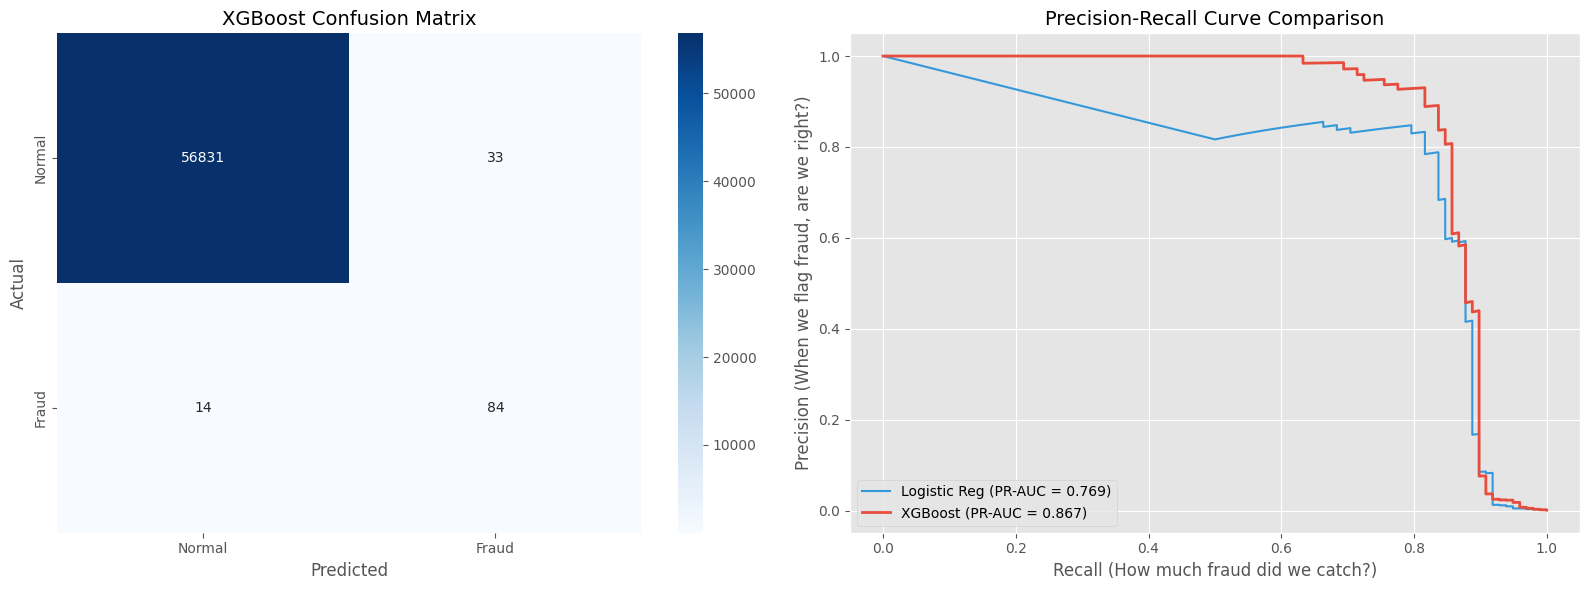

In [5]:
# Phase 4: Model Training and Evaluation

from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.metrics import classification_report, precision_recall_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure you have the balanced training data (X_sm, y_sm) 
# and the original imbalanced testing data (X_test, y_test) from the previous step.

# 1. Train Baseline Logistic Regression
print("Training Logistic Regression (Baseline)...")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_sm, y_sm)

# Predict on the UNBALANCED test set
y_pred_log = log_reg.predict(X_test)
y_prob_log = log_reg.predict_proba(X_test)[:, 1]

# 2. Train Advanced XGBoost Model
print("Training XGBoost Classifier (This may take a moment)...")
xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_clf.fit(X_sm, y_sm)

# Predict on the UNBALANCED test set
y_pred_xgb = xgb_clf.predict(X_test)
y_prob_xgb = xgb_clf.predict_proba(X_test)[:, 1]

# 3. Evaluation Metrics Comparison
print("\n--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_log))

print("\n--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb))

# 4. Visualize the Results

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Confusion Matrix for XGBoost
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0], 
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
ax[0].set_title('XGBoost Confusion Matrix', fontsize=14)
ax[0].set_ylabel('Actual')
ax[0].set_xlabel('Predicted')

# Plot B: Precision-Recall Curve Comparison
# Calculate PR curves
precision_log, recall_log, _ = precision_recall_curve(y_test, y_prob_log)
pr_auc_log = auc(recall_log, precision_log)

precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
pr_auc_xgb = auc(recall_xgb, precision_xgb)

# Plot curves
ax[1].plot(recall_log, precision_log, label=f'Logistic Reg (PR-AUC = {pr_auc_log:.3f})', color='#3498db')
ax[1].plot(recall_xgb, precision_xgb, label=f'XGBoost (PR-AUC = {pr_auc_xgb:.3f})', color='#e74c3c', linewidth=2)
ax[1].set_title('Precision-Recall Curve Comparison', fontsize=14)
ax[1].set_xlabel('Recall (How much fraud did we catch?)')
ax[1].set_ylabel('Precision (When we flag fraud, are we right?)')
ax[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

--- Financial Impact Analysis ---
Logistic Regression Net Impact: $-11,310.00
XGBoost Net Impact: $7,905.00

Value added by choosing XGBoost over Baseline: $19,215.00


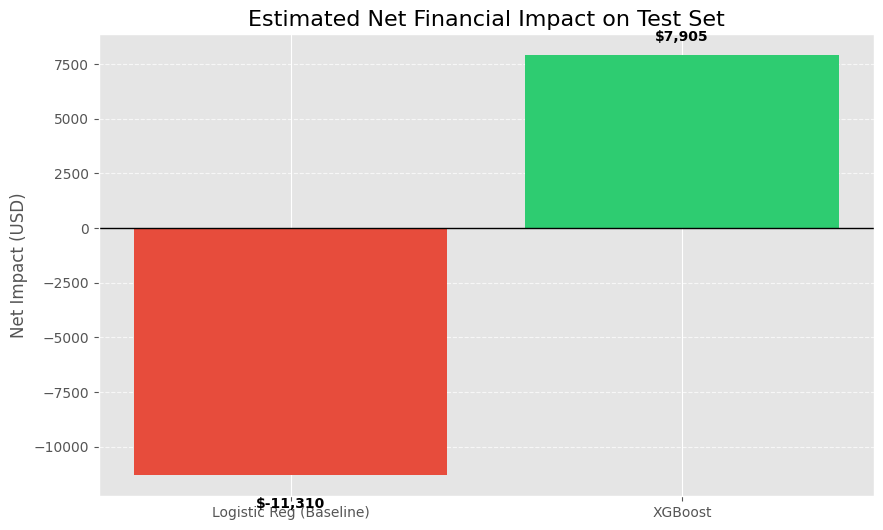

In [6]:
# Phase 5: Financial Impact Analysis

import numpy as np
import matplotlib.pyplot as plt

# 1. Define Business Costs/Values (Hypothetical but realistic)
# Note: In a real scenario, these would be derived from business metrics.
avg_transaction_value = 120 # Assume average transaction is $120

cost_false_positive = 15    # Cost of customer service call + friction
cost_false_negative = avg_transaction_value  # We lose the transaction amount
value_true_positive = avg_transaction_value  # We saved the transaction amount
value_true_negative = 0     # Baseline, no extra cost or savings

# 2. Extract Confusion Matrix Values for XGBoost
# (Using the values from your provided results)
TP_xgb = 84
FP_xgb = 33
FN_xgb = 14
TN_xgb = 56831

# 3. Extract Confusion Matrix Values for Logistic Regression
# We have to calculate these based on the classification report
# Total Fraud = 98. Recall = 0.92 -> TP = 98 * 0.92 = 90. FN = 98 - 90 = 8.
# Precision = 0.06 -> TP / (TP + FP) = 0.06 -> 90 / (90 + FP) = 0.06 -> 90 = 0.06 * 90 + 0.06 * FP -> 84.6 = 0.06 * FP -> FP = 1410
TP_log = 90
FP_log = 1410
FN_log = 8
TN_log = 56864 - FP_log # Total normal is 56864

# 4. Calculate Expected Value (Financial Impact)
def calculate_financial_impact(TP, FP, FN):
    savings = (TP * value_true_positive)
    costs = (FP * cost_false_positive) + (FN * cost_false_negative)
    net_impact = savings - costs
    return savings, costs, net_impact

sav_xgb, cost_xgb, net_xgb = calculate_financial_impact(TP_xgb, FP_xgb, FN_xgb)
sav_log, cost_log, net_log = calculate_financial_impact(TP_log, FP_log, FN_log)

print("--- Financial Impact Analysis ---")
print(f"Logistic Regression Net Impact: ${net_log:,.2f}")
print(f"XGBoost Net Impact: ${net_xgb:,.2f}")
print(f"\nValue added by choosing XGBoost over Baseline: ${(net_xgb - net_log):,.2f}")

# 5. Visualize the Business Impact
models = ['Logistic Reg (Baseline)', 'XGBoost']
net_impacts = [net_log, net_xgb]
colors = ['#e74c3c' if val < 0 else '#2ecc71' for val in net_impacts]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, net_impacts, color=colors)

# Add data labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (500 if yval > 0 else -1000), 
             f'${yval:,.0f}', ha='center', va='bottom' if yval > 0 else 'top', fontweight='bold')

plt.axhline(0, color='black', linewidth=1)
plt.title('Estimated Net Financial Impact on Test Set', fontsize=16)
plt.ylabel('Net Impact (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()